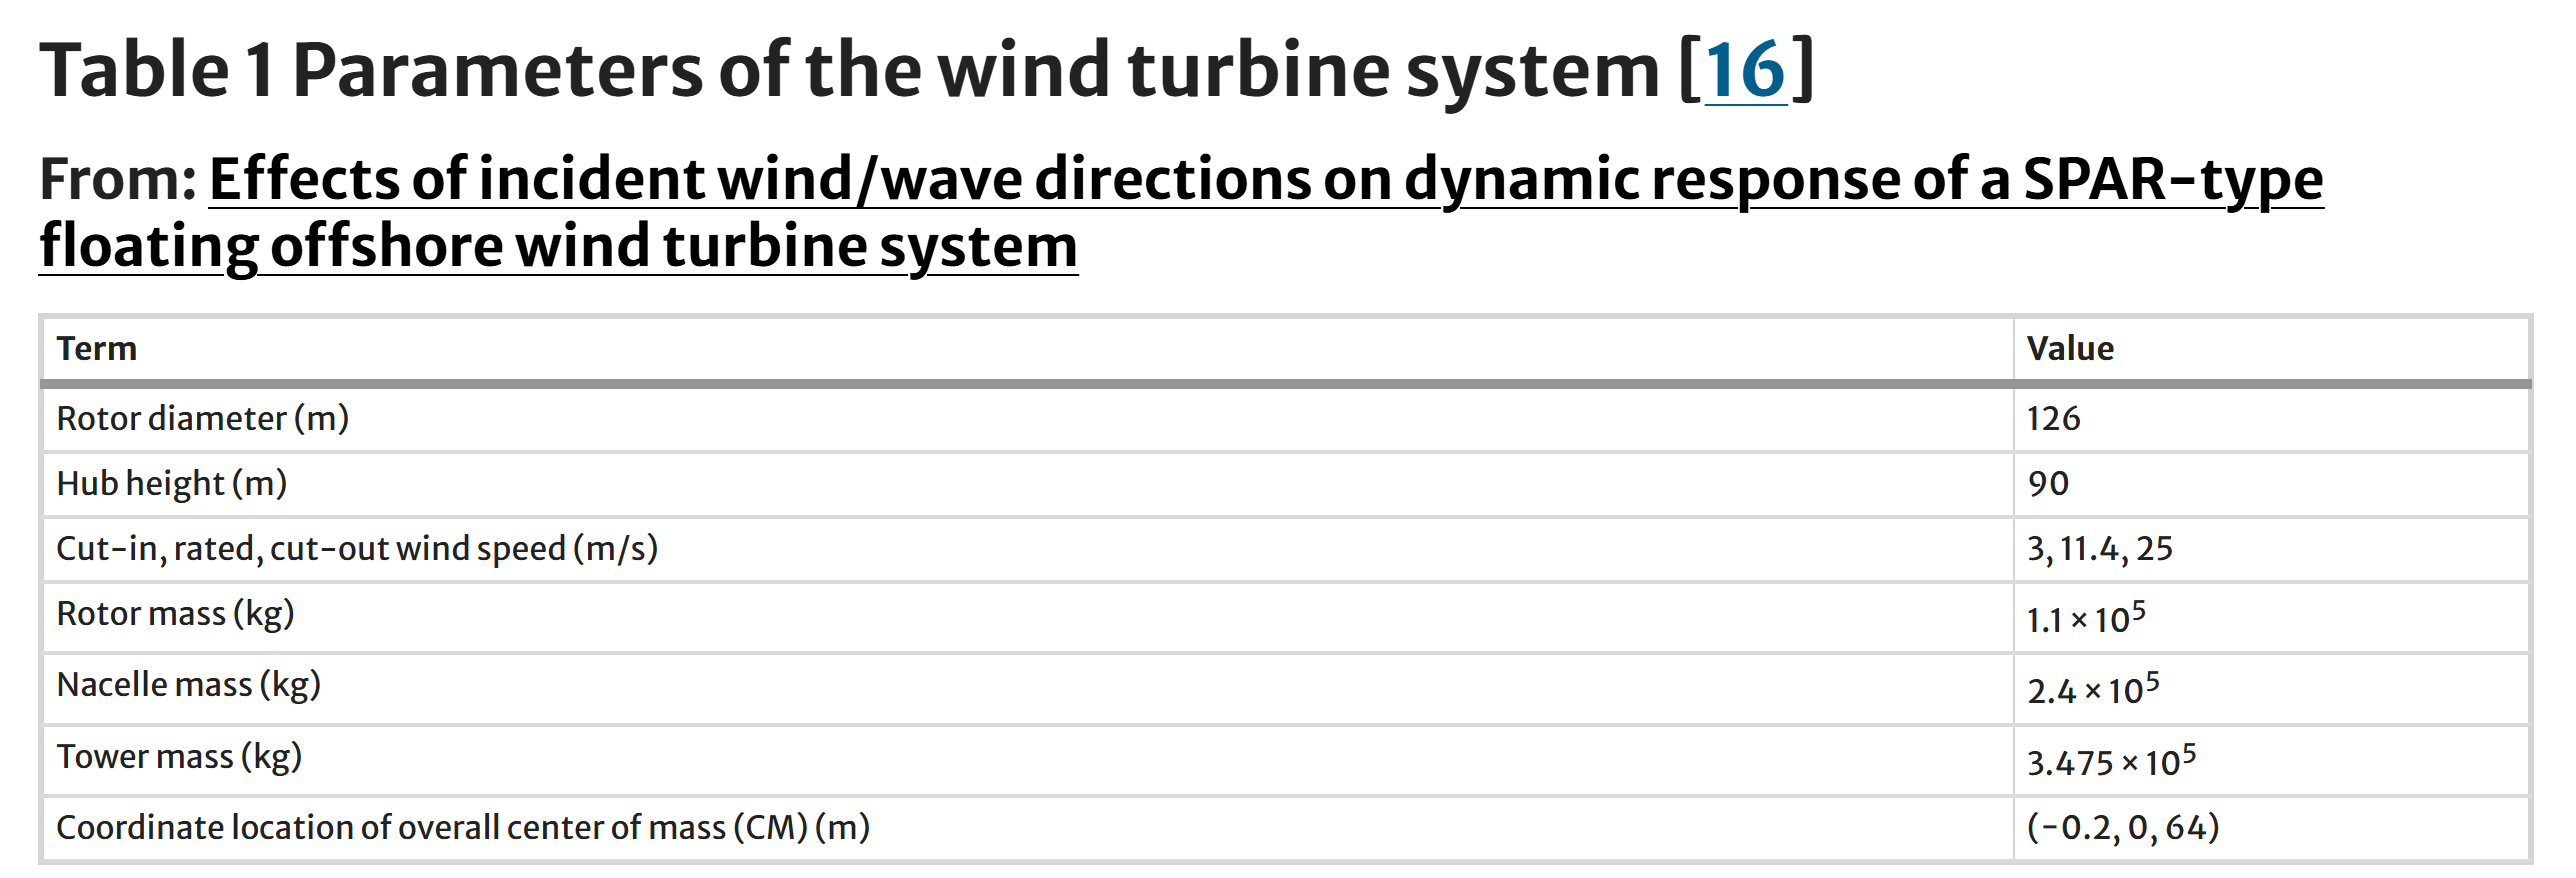

In [10]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt


data_dir= r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'
eva_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA'
power_production_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\power_production'

#load wind data
df_wind = pd.read_csv(f"{data_dir}/wind_data_sines_2010_2020.csv", index_col=0, parse_dates=True)

#check timestep
dt= df_wind.index[1] - df_wind.index[0]
dt_hours = dt.total_seconds() / 3600
print(f"Time step: {dt_hours:.2f} hours")
print(f"Total records: {len(df_wind)}")
print (f"Data range: {df_wind.index[0]} to {df_wind.index[-1]}")

Time step: 3.00 hours
Total records: 32144
Data range: 2010-01-01 00:00:00 to 2020-12-31 21:00:00


In [12]:

#correction hub height
alpha = 0.14
z_ref = 100  # m
z_hub = 90  # m
df_wind['U_hub'] = df_wind['wind_speed_100m_ms'] * (z_hub / z_ref)**alpha


print(f"Mean wind speed at 100 m: {df_wind['wind_speed_100m_ms'].mean():.2f} m/s")
print(f"Mean wind speed at hub height (90 m): {df_wind['U_hub'].mean():.2f} m/s")

Mean wind speed at 100 m: 7.29 m/s
Mean wind speed at hub height (90 m): 7.19 m/s


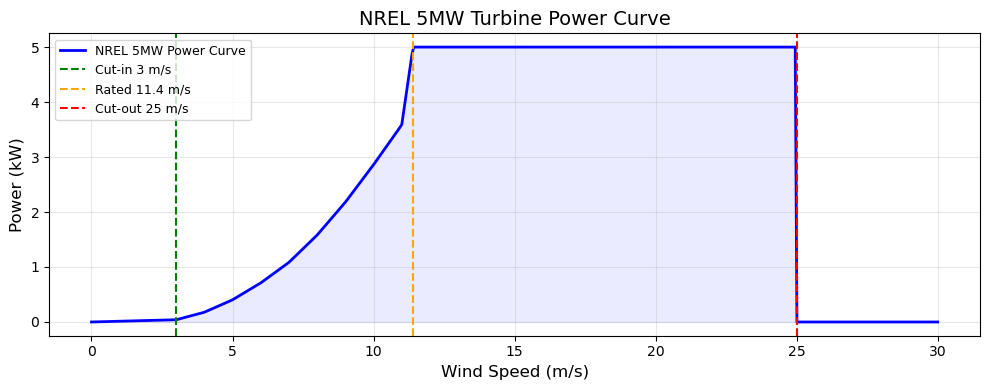

Mean power at hub height: 1632.18 kW
% time at rated power    : 11.9%
% time producing power   : 89.3%
% time below cut-in      : 10.7%
% time above cut-out     : 0.0%


In [19]:

# ── NREL 5MW power curve ───────────────────────────────────────────
pc_wind_ms = np.array([0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 11.4,
                    12, 13, 14, 15, 16, 17, 18, 19, 20,
                    21, 22, 23, 24, 25, 25.01, 50])
pc_power_kW = np.array([0, 40, 177, 403, 710, 1084, 1581, 2178,
                     2860, 3586, 5000, 5000, 5000, 5000, 5000,
                     5000, 5000, 5000, 5000, 5000, 5000, 5000,
                     5000, 5000, 5000, 0, 0])  # kW

# Apply power curve to hub-height wind time series
df_wind['power_kW'] = np.interp(df_wind['U_hub'], pc_wind_ms, pc_power_kW)

#plot power curve
u_range = np.linspace(0, 30,500)
p_range = np.interp(u_range, pc_wind_ms, pc_power_kW)

plt.figure(figsize=(10, 4))
plt.plot(u_range, p_range/1000, 'b-', linewidth = 2, label = 'NREL 5MW Power Curve')
plt.axvline(3, color='green', linestyle='--', label='Cut-in 3 m/s')
plt.axvline(11.4, color='orange', linestyle='--', label='Rated 11.4 m/s')
plt.axvline(25, color='red', linestyle='--', label='Cut-out 25 m/s')
plt.fill_between(u_range, p_range / 1000, alpha=0.08, color='blue')
plt.xlabel('Wind Speed (m/s)', fontsize=12)
plt.ylabel('Power (kW)', fontsize=12)
plt.title('NREL 5MW Turbine Power Curve', fontsize=14)
plt.legend(fontsize=9, loc='upper left') 
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.savefig(f"{power_production_dir}/wind_power_curve.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Mean power at hub height: {df_wind['power_kW'].mean():.2f} kW")
print(f"% time at rated power    : {(df_wind['power_kW'] >= 4999).mean()*100:.1f}%")
print(f"% time producing power   : {((df_wind['U_hub'] >= 3) & (df_wind['U_hub'] <= 25)).mean()*100:.1f}%")
print(f"% time below cut-in      : {(df_wind['U_hub'] < 3).mean()*100:.1f}%")
print(f"% time above cut-out     : {(df_wind['U_hub'] > 25).mean()*100:.1f}%")

Jonkman et al. (2009), NREL/TP-500-38060 

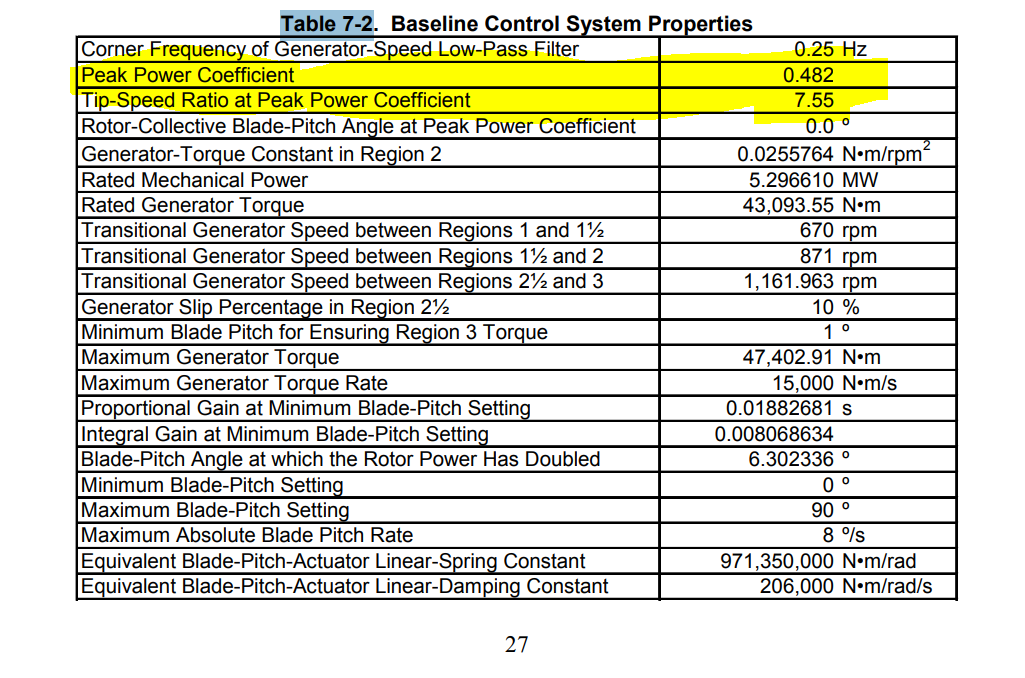

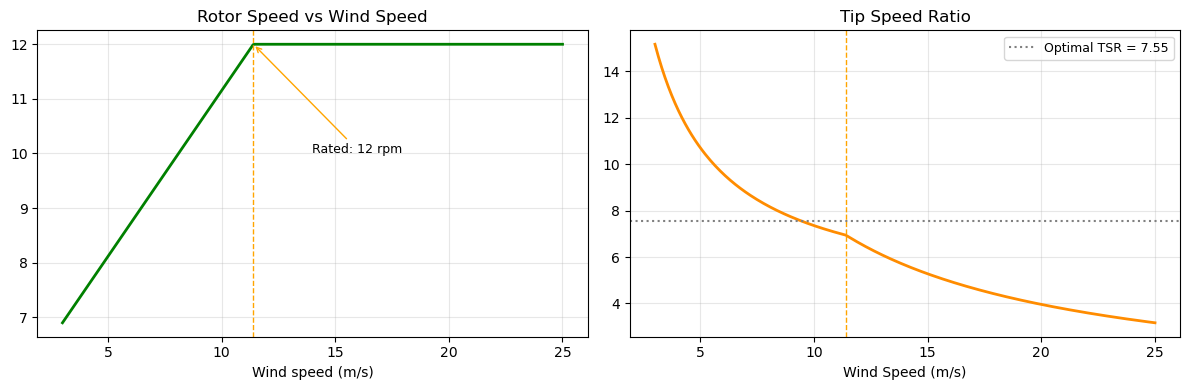

TSR at rated (11.4 m/s): 6.94  (should be ≈ 7.55)


In [21]:
#tip speed ratio
R = 63  # m rotor radius
omega_min = 6.9 # rpm
omega_rated = 12  # rpm
U_cut_in = 3  # m/s
U_rated = 11.4  # m/s
U_cut_out = 25  # m/s
TSR_opt = 7.55  # optimal tip speed ratio

U_vec = np.linspace(U_cut_in, U_cut_out, 300)

Omega_rpm= np.where(U_vec < U_rated, 
                    omega_min + (omega_rated - omega_min) * (U_vec - U_cut_in) / (U_rated - U_cut_in),
                    omega_rated)
Omega_rads = Omega_rpm * 2 * np.pi / 60 

TSR_vec = Omega_rads * R / U_vec

df_wind['Omega_rpm'] = np.interp(df_wind['U_hub'], 
                                 [U_cut_in, U_rated, U_cut_out],
                                 [omega_min, omega_rated, omega_rated],
                                 left=0, right=0)
df_wind['Omega_rads'] = df_wind['Omega_rpm'] * 2 * np.pi / 60
df_wind['TSR'] = np.where(df_wind['U_hub'] > 0, 
                           df_wind['Omega_rads'] * R / df_wind['U_hub'].replace(0, np.nan),
                           0)

#plot

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(U_vec, Omega_rpm, 'g-', linewidth=2)
ax1.axvline(U_rated, color='orange', linestyle='--', linewidth=1)
ax1.set_xlabel('Wind speed (m/s)', fontsize=10)
ax1.set_title('Rotor Speed vs Wind Speed', fontsize=12)
ax1.annotate(f'Rated: {omega_rated} rpm', xy=(U_rated, omega_rated),
              xytext=(14, 10), fontsize=9,
              arrowprops=dict(arrowstyle='->', color='orange'))
ax1.grid(True, alpha=0.3)

ax2.plot(U_vec, TSR_vec, 'darkorange', linewidth=2)
ax2.axhline(TSR_opt, color='gray', linestyle=':', linewidth=1.5,
             label=f'Optimal TSR = {TSR_opt}')
ax2.axvline(U_rated, color='orange', linestyle='--', linewidth=1)
ax2.set_xlabel('Wind Speed (m/s)', fontsize=10)
ax2.set_title('Tip Speed Ratio', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{power_production_dir}/rotor_speed_tsr.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"TSR at rated (11.4 m/s): {np.interp(11.4, U_vec, TSR_vec):.2f}  (should be ≈ 7.55)")

$$T = \frac{1}{2}\, \rho\, A\, C_T(U)\, U^2$$
where:
- $\rho = 1.225$ kg/m³: air density at sea level, standard atmosphere (ISO 2533:1975)
- $A = \pi R^2 = \pi \times 63^2 = 12{,}469$ m²: rotor swept area
- $C_T(U)$: thrust coefficient as a function of wind speed, digitised from **Figure 9-1** of Jonkman et al. (2009) (RotThrust curve)

https://automeris.io/wpd/

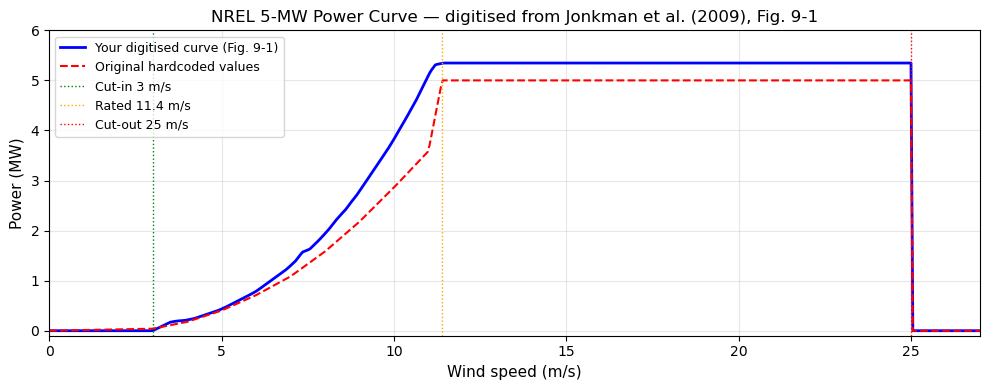

Max digitised power : 5347.0 kW  (should be ~5000 kW)
Mean power at hub   : 1937.5 kW


In [22]:
import numpy as np

# ── RAW DIGITISED DATA FROM WEBPLOTDIGITIZER 
# Source: Jonkman et al. (2009), NREL/TP-500-38060, Figure 9-1, GenPwr curve
# Digitised manually using WebPlotDigitizer (automeris.io)

raw = np.array([
    [3.527, 0.174], [3.727, 0.195], [3.934, 0.205], [4.229, 0.247],
    [4.450, 0.300], [4.676, 0.352], [4.897, 0.403], [5.117, 0.470],
    [5.336, 0.547], [5.555, 0.625], [5.796, 0.708], [6.016, 0.793],
    [6.234, 0.901], [6.453, 1.010], [6.672, 1.120], [6.891, 1.230],
    [7.132, 1.381], [7.346, 1.570], [7.556, 1.628], [7.759, 1.762],
    [7.942, 1.894], [8.120, 2.032], [8.287, 2.181], [8.445, 2.306],
    [8.615, 2.432], [8.761, 2.569], [8.909, 2.696], [9.046, 2.833],
    [9.183, 2.973], [9.321, 3.113], [9.458, 3.254], [9.596, 3.395],
    [9.733, 3.536], [9.860, 3.667], [9.978, 3.799], [10.095, 3.937],
    [10.212, 4.080], [10.330, 4.216], [10.447, 4.360], [10.564, 4.504],
    [10.671, 4.638], [10.768, 4.774], [10.865, 4.912], [10.963, 5.046],
    [11.060, 5.179], [11.206, 5.314], [11.439, 5.347], [11.660, 5.347],
    # above rated: flat at ~5.347 MW all the way to cut-out
    [25.0,  5.347],
])

U_dig  = raw[:, 0]   # wind speed [m/s]
P_dig  = raw[:, 1]   # power [MW]  ← note: YOUR data is in MW, not kW!

# ── CONVERT TO KW AND ADD CUT-OUT ────────────────────────────────────────────
# Add the two boundary points that WebPlotDigitizer won't give you:
# before cut-in → 0 kW, after cut-out → 0 kW

U_pc = np.concatenate([[0.0, 3.0], U_dig, [25.01, 50.0]])
P_pc = np.concatenate([[0.0, 0.0], P_dig * 1000, [0.0,   0.0]])  # MW → kW

# ── APPLY TO TIME SERIES ─────────────────────────────────────────────────────
df_wind['power_kW'] = np.interp(df_wind['U_hub'], U_pc, P_pc)

# ── PLOT: COMPARE YOUR DIGITISED CURVE VS THE ORIGINAL LOOKUP TABLE ──────────
# Original hardcoded values (for comparison)
pc_wind_orig = np.array([0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 11.4,
                          12, 25, 25.01, 50])
pc_power_orig = np.array([0, 40, 177, 403, 710, 1084, 1581, 2178,
                           2860, 3586, 5000, 5000, 5000, 0, 0])

u_plot = np.linspace(0, 27, 500)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(u_plot, np.interp(u_plot, U_pc, P_pc) / 1000,
        'b-', linewidth=2, label='Your digitised curve (Fig. 9-1)')
ax.plot(u_plot, np.interp(u_plot, pc_wind_orig, pc_power_orig) / 1000,
        'r--', linewidth=1.5, label='Original hardcoded values')
ax.axvline(3,    color='green',  linestyle=':', linewidth=1, label='Cut-in 3 m/s')
ax.axvline(11.4, color='orange', linestyle=':', linewidth=1, label='Rated 11.4 m/s')
ax.axvline(25,   color='red',    linestyle=':', linewidth=1, label='Cut-out 25 m/s')
ax.set_xlabel('Wind speed (m/s)', fontsize=11)
ax.set_ylabel('Power (MW)', fontsize=11)
ax.set_title('NREL 5-MW Power Curve — digitised from Jonkman et al. (2009), Fig. 9-1', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 27)
ax.set_ylim(-0.1, 6)
plt.tight_layout()
plt.savefig(f"{power_production_dir}/power_curve_digitised.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Max digitised power : {P_pc.max():.1f} kW  (should be ~5000 kW)")
print(f"Mean power at hub   : {df_wind['power_kW'].mean():.1f} kW")

In [ ]:
#thrust force
rho = 1.225  # kg/m³ ISO 2533:1975 standard atmosphere
A = np.pi * (R**2)  # m²
print(f"Rotor swept area: {A:.2f} m²")

ct_wind_ms = np.array([ 3,   4,   5,   6,   7,   8,   9,  10, 11, 11.4,
                        12,  13,  14,  15,  16,  18,  20,  22,  25])
ct_CT      = np.array([0.82, 0.83, 0.85, 0.86, 0.86, 0.85, 0.84, 0.83, 0.81, 0.81,
                        0.67, 0.55, 0.46, 0.39, 0.34, 0.27, 0.22, 0.19, 0.16])

thrust_force = 0.5 * rho * A * U_hub**2
print(f"Thrust force at rated wind speed: {thrust_force:.2f} N")

In [3]:
df_wind['power_kW'] = np.interp(df_wind['U_hub'], pc_wind, pc_power)

print(f"Mean power production at hub height: {df_wind['power_kW'].mean():.2f} kW")
print(f"Max power production at hub height: {df_wind['power_kW'].max():.2f} kW")
print(f"% time at rated:     {(df_wind['power_kW'] >= 4999).mean()*100:.1f}%")
print(f"% time cut-in to cut-out: {((df_wind['U_hub'] >= 3) & (df_wind['U_hub'] <= 25)).mean()*100:.1f}%")
print(f"% time below cut-in: {(df_wind['U_hub'] < 3).mean()*100:.1f}%")
print(f"% time above cut-out:{(df_wind['U_hub'] > 25).mean()*100:.1f}%")



Mean power production at hub height: 1622.52 kW
Max power production at hub height: 5000.00 kW
% time at rated:     11.8%
% time cut-in to cut-out: 89.2%
% time below cut-in: 10.8%
% time above cut-out:0.0%


In [8]:
print(df_wind.index[1] - df_wind.index[0])  # What is the actual timestep?

0 days 03:00:00


In [6]:
#annual energy production 

dt_hours = 3
n_years = 10
AEP_kWh = df_wind['power_kW'].sum() * dt_hours
AEP_annual_MWh = AEP_kWh / 1000 / n_years 
AEP_annual_GWh = AEP_annual_MWh / 1000

print(f"Annual energy production:")
print(f"{AEP_kWh:.2f} kWh")
print(f"{AEP_annual_MWh:.2f} MWh")



Annual energy production:
142249336.63 kWh
14224.93 MWh


In [7]:
#capacity factor 
P_rated = 5000 # kW
T_hours = 365 * 24
CF = AEP_annual_MWh / (P_rated * T_hours / 1000)  

print("Capacity factor: {:.2f}%".format(CF * 100))

Capacity factor: 32.48%


SOMETHING IS WRONG, IT SHOULD BE AROUND 40-55% !!!!!!!!!!!

AEP variability:
Mean annual AEP: 14224.93 MWh
Min annual AEP: 12601.95 MWh
Max annual AEP: 15499.06 MWh
Standard deviation: 983.48 MWh


C:\Users\Carolina\AppData\Local\Temp\ipykernel_4556\512907039.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


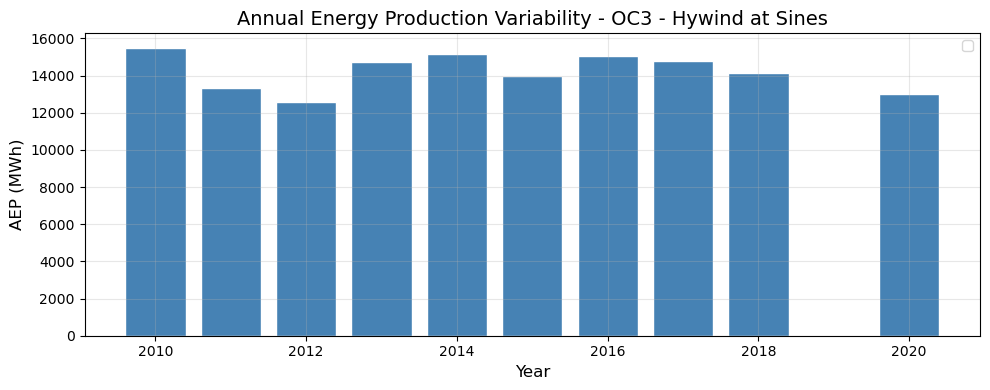

In [ ]:
# annual variability 

df_wind['year']= df_wind.index.year
annual_aep = df_wind.groupby('year')['power_kW'].sum() * dt_hours / 1000  

print("AEP variability:")
print(f"Mean annual AEP: {annual_aep.mean():.2f} MWh")
print(f"Min annual AEP: {annual_aep.min():.2f} MWh")
print(f"Max annual AEP: {annual_aep.max():.2f} MWh")
print(f"Standard deviation: {annual_aep.std():.2f} MWh")

plt.figure(figsize=(10, 4))
plt.bar(annual_aep.index, annual_aep.values, color='steelblue', edgecolor='white')
plt.xlabel('Year', fontsize=12)
plt.ylabel('AEP (MWh)', fontsize=12)
plt.title('Annual Energy Production Variability - OC3 - Hywind at Sines', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{power_production_dir}/annual_aep_variability.png", dpi=300, bbox_inches='tight')
plt.show()